# Core Benchmark Analysis

Notebook ini digunakan untuk mempresentasikan dan menganalisis hasil benchmark inti yang dihasilkan oleh pipeline `experiments/scripts/run_core_checkpoint.py`

Notebook ini berfungsi untuk:
- memverifikasi bahwa artefak yang dibaca sesuai dengan run yang dimaksud,
- menyajikan hasil dalam bentuk tabel dan visualisasi yang lebih mudah ditafsirkan,
- mendokumentasikan interpretasi teknikal terhadap performa masing-masing engine.


## Content

Alur analisis pada notebook ini disusun secara berurutan agar konsisten dengan logika evaluasi eksperimental.

1. **Provenance and Experimental Design**
2. **Audit Validity**
3. **Scenario-Level Feasibility**
4. **Stability Analysis**
5. **Runtime vs Feasibility Trade-off**
6. **Action Pattern Analysis**
7. **Candidate-Level Spot Checks**
8. **Conclusion**


In [30]:
from __future__ import annotations

import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import HTML, Markdown, display

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

ENGINE_ORDER = ["dice", "ocean", "ft", "nn"]
SCENARIO_ORDER = ["all_mutable", "lifestyle_combo", "bmi_only", "activity_only", "tight_bounds", "no_mutable"]
ENGINE_COLORS = {"dice": "#1f77b4", "ocean": "#ff7f0e", "ft": "#2ca02c", "nn": "#d62728"}

def style_metric_table(
    frame: pd.DataFrame,
    percent_cols: list[str] | None = None,
    precision: int = 3,
    hide_index: bool = False,
):
    percent_cols = percent_cols or []
    formatters = {col: lambda x: f"{x:.1%}" if pd.notna(x) else "-" for col in percent_cols if col in frame.columns}
    for col in frame.columns:
        if col in formatters:
            continue
        if pd.api.types.is_float_dtype(frame[col]):
            formatters[col] = lambda x, p=precision: f"{x:.{p}f}" if pd.notna(x) else "-"
    styled = frame.style.format(formatters)
    if hide_index:
        styled = styled.hide(axis="index")
    return styled

def make_summary_cards(items: list[tuple[str, str, str]]) -> str:
    cards = []
    for title, value, subtitle in items:
        cards.append(
            f"<div style='padding:14px 16px;border:1px solid #d0d7de;border-radius:10px;background:#f8fafc;min-width:180px'>"
            f"<div style='font-size:12px;color:#475569;text-transform:uppercase;letter-spacing:0.04em'>{title}</div>"
            f"<div style='font-size:28px;font-weight:700;color:#0f172a;margin-top:4px'>{value}</div>"
            f"<div style='font-size:12px;color:#64748b;margin-top:4px'>{subtitle}</div>"
            "</div>"
        )
    return "<div style='display:flex;gap:12px;flex-wrap:wrap;margin:10px 0 18px 0'>" + "".join(cards) + "</div>"

def extract_engine_from_source(path_text: str) -> str:
    parts = Path(path_text).parts
    if "baselines" in parts:
        idx = parts.index("baselines")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return "unknown"


In [31]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Repo root not found from notebook path.")


REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = REPO_ROOT / "experiments" / "results"
LATEST_COMPARISON_POINTER = RESULTS_ROOT / "latest" / "comparison.txt"

if not LATEST_COMPARISON_POINTER.exists():
    raise FileNotFoundError(f"Latest comparison pointer not found: {LATEST_COMPARISON_POINTER}")

COMPARISON_ROOT = Path(LATEST_COMPARISON_POINTER.read_text(encoding="utf-8").strip())
CHECKPOINT_REPORT_PATH = COMPARISON_ROOT / "checkpoint_report.md"
COMPARISON_REPORT_PATH = COMPARISON_ROOT / "comparison_report.md"
CHECKPOINT_MANIFEST_PATH = COMPARISON_ROOT / "checkpoint_manifest.json"
COMPARISON_MANIFEST_PATH = COMPARISON_ROOT / "comparison_manifest.json"
AUDIT_REPORT_PATH = COMPARISON_ROOT / "audit_report.json"
COMBINED_DIR = COMPARISON_ROOT / "combined"

SCENARIO_SUMMARY_PATH = COMBINED_DIR / "scenario_summary.csv"
STABILITY_SUMMARY_PATH = COMBINED_DIR / "stability_summary.csv"
CANDIDATES_PATH = COMBINED_DIR / "candidates.csv"
INPUTS_PATH = COMBINED_DIR / "inputs.csv"

comparison_manifest = json.loads(COMPARISON_MANIFEST_PATH.read_text(encoding="utf-8"))
checkpoint_manifest = json.loads(CHECKPOINT_MANIFEST_PATH.read_text(encoding="utf-8"))
audit_report = json.loads(AUDIT_REPORT_PATH.read_text(encoding="utf-8"))

scenario_df = pd.read_csv(SCENARIO_SUMMARY_PATH) if SCENARIO_SUMMARY_PATH.exists() else pd.DataFrame()
stability_df = pd.read_csv(STABILITY_SUMMARY_PATH) if STABILITY_SUMMARY_PATH.exists() else pd.DataFrame()
candidates_df = pd.read_csv(CANDIDATES_PATH) if CANDIDATES_PATH.exists() else pd.DataFrame()
inputs_df = pd.read_csv(INPUTS_PATH) if INPUTS_PATH.exists() else pd.DataFrame()

print(f"Comparison root: {COMPARISON_ROOT}")
print(f"Scenario rows: {len(scenario_df)} | Stability rows: {len(stability_df)} | Candidate rows: {len(candidates_df)}")


Comparison root: D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260506_152321
Scenario rows: 24 | Stability rows: 4 | Candidate rows: 168


## 1. Provenance and Experimental Design

Bagian ini memastikan bahwa notebook membaca artefak hasil yang benar dan bahwa konfigurasi eksperimen yang divisualisasikan memang sesuai dengan benchmark inti yang direncanakan. 

In [32]:
design_summary = pd.DataFrame(
    [
        {
            "engines": ", ".join(comparison_manifest.get("engines", [])),
            "scenario_count": len(comparison_manifest.get("scenario_configs", [])),
            "scenario_limit": comparison_manifest.get("scenario_limit"),
            "stability_limit": comparison_manifest.get("stability_limit"),
            "repeat_count": comparison_manifest.get("repeat_count"),
            "scenario_timeout_seconds": comparison_manifest.get("scenario_timeout_seconds"),
            "stability_timeout_seconds": comparison_manifest.get("stability_timeout_seconds"),
            "checkpoint_ok": checkpoint_manifest.get("ok"),
            "fail_on_timeout": audit_report.get("fail_on_timeout"),
        }
    ]
)
display(design_summary.T.rename(columns={0: "value"}))


,value
engines,"dice, ocean, ft, nn"
scenario_count,6
scenario_limit,10
stability_limit,10
repeat_count,5
scenario_timeout_seconds,180
stability_timeout_seconds,180
checkpoint_ok,True
fail_on_timeout,True


## 2. Audit Validity

Validitas run harus selalu dibaca **sebelum** performa engine ditafsirkan. Pada penelitian yang berorientasi evaluasi komparatif, hasil yang secara numerik terlihat baik tetap tidak dapat diperlakukan sebagai evidence final apabila cakupan run tidak lengkap atau audit menunjukkan kegagalan.


In [33]:
audit_overview = pd.DataFrame(
    [
        {
            "checkpoint_status": "PASS" if audit_report.get("ok") else "FAIL",
            "observed_engines": ", ".join(audit_report.get("observed_engines", [])),
            "scenario_rows": audit_report.get("row_counts", {}).get("scenario"),
            "stability_rows": audit_report.get("row_counts", {}).get("stability"),
            "candidate_rows": audit_report.get("row_counts", {}).get("candidates"),
            "error_count": len(audit_report.get("errors", [])),
            "warning_count": len(audit_report.get("warnings", [])),
        }
    ]
)
display(audit_overview.T.rename(columns={0: "value"}))

if audit_report.get("errors"):
    display(Markdown("**Audit errors**"))
    for item in audit_report["errors"]:
        display(Markdown(f"- {item}"))

if audit_report.get("warnings"):
    display(Markdown("**Audit warnings**"))
    for item in audit_report["warnings"]:
        display(Markdown(f"- {item}"))


,value
checkpoint_status,PASS
observed_engines,"dice, ft, nn, ocean"
scenario_rows,24
stability_rows,4
candidate_rows,168
error_count,0
warning_count,0


## 3. Scenario-Level Feasibility

Section ini membandingkan kemampuan setiap engine untuk menghasilkan solusi counterfactual yang feasible pada masing-masing skenario kendala. Ringkasan pada `scenario_summary.csv` menggunakan **top-ranked candidate per request** sebagai basis agregasi utama, sehingga interpretasi antar engine menjadi lebih adil meskipun jumlah kandidat mentah yang dihasilkan masing-masing engine berbeda.


engine,scenario,step_status,feasible_rate,target_success_rate,mean_runtime_ms,reason_counts,requests_with_candidates
dice,all_mutable,completed,100.0%,100.0%,252.700,"{""OK"": 10}",10
ocean,all_mutable,completed,70.0%,100.0%,3244.400,"{""OK"": 7, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 2, ""MEDICAL_RULE_VIOLATION_ONLY"": 1}",7
ft,all_mutable,completed,40.0%,100.0%,82.700,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 6, ""OK"": 4}",4
nn,all_mutable,completed,100.0%,100.0%,502.900,"{""OK"": 10}",10
dice,lifestyle_combo,completed,100.0%,100.0%,3475.600,"{""OK"": 10}",10
ocean,lifestyle_combo,completed,70.0%,100.0%,3209.900,"{""OK"": 7, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 2, ""MEDICAL_RULE_VIOLATION_ONLY"": 1}",7
ft,lifestyle_combo,completed,40.0%,100.0%,111.300,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 6, ""OK"": 4}",4
nn,lifestyle_combo,completed,100.0%,100.0%,351.100,"{""OK"": 10}",10
dice,bmi_only,completed,70.0%,100.0%,189.200,"{""OK"": 7, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 3}",7
ocean,bmi_only,completed,30.0%,100.0%,3217.100,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 7, ""OK"": 3}",3


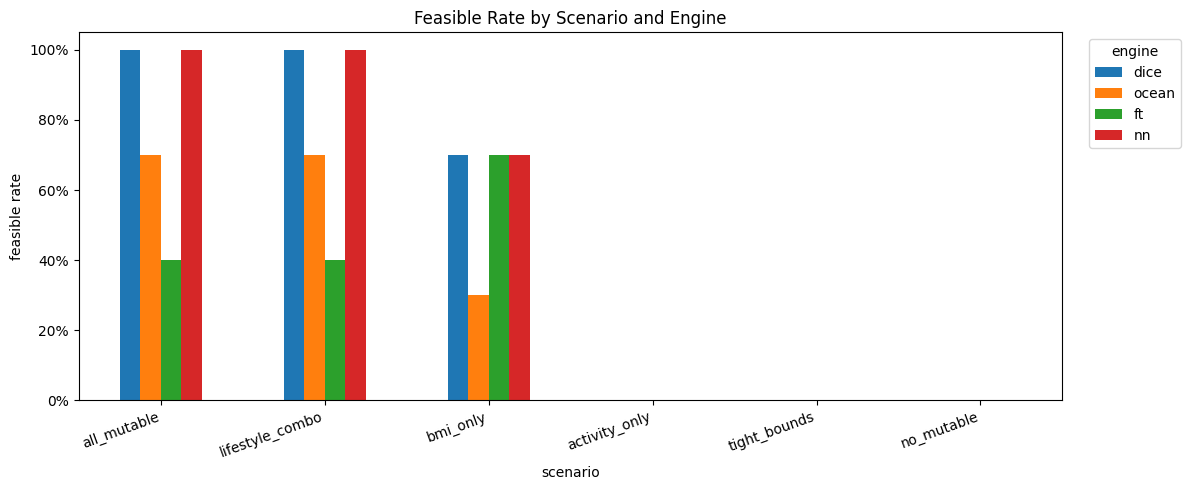

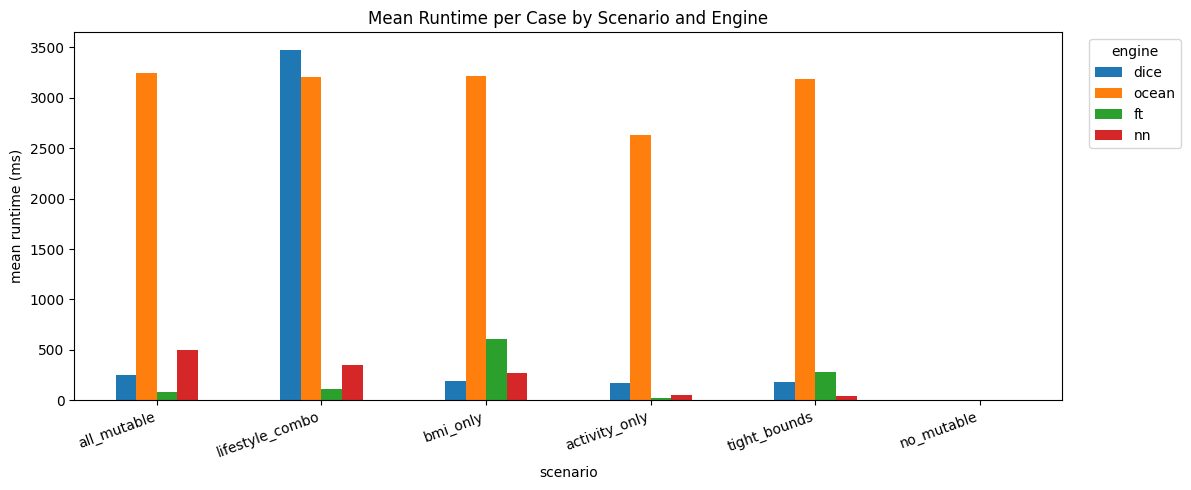

In [34]:
scenario_view = scenario_df.copy()
if not scenario_view.empty:
    scenario_view["engine"] = pd.Categorical(scenario_view["source_file"].map(extract_engine_from_source), categories=ENGINE_ORDER, ordered=True)
    scenario_view["scenario"] = pd.Categorical(scenario_view["scenario"], categories=SCENARIO_ORDER, ordered=True)
    scenario_view = scenario_view[["engine", "scenario", "step_status", "feasible_rate", "target_success_rate", "mean_runtime_ms", "reason_counts", "requests_with_candidates"]].sort_values(["scenario", "engine"]).reset_index(drop=True)
    display(style_metric_table(scenario_view, percent_cols=["feasible_rate", "target_success_rate"], hide_index=True))
    heatmap_df = scenario_view.pivot(index="engine", columns="scenario", values="feasible_rate").reindex(index=ENGINE_ORDER, columns=SCENARIO_ORDER)
    ax = heatmap_df.T.plot(kind="bar", figsize=(12, 5), color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in heatmap_df.index])
    ax.set_title("Feasible Rate by Scenario and Engine")
    ax.set_ylabel("feasible rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title="engine", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    runtime_pivot = scenario_view.pivot(index="engine", columns="scenario", values="mean_runtime_ms").reindex(index=ENGINE_ORDER, columns=SCENARIO_ORDER)
    ax = runtime_pivot.T.plot(kind="bar", figsize=(12, 5), color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in runtime_pivot.index])
    ax.set_title("Mean Runtime per Case by Scenario and Engine")
    ax.set_ylabel("mean runtime (ms)")
    ax.legend(title="engine", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## 4. Stability Analysis

Stability analysis mengevaluasi apakah engine menghasilkan rekomendasi yang konsisten ketika proses pencarian diulang pada kasus yang sama. Dalam konteks tree-ensemble counterfactuals, dimensi ini penting karena salah satu masalah utama yang ingin diatasi adalah ketidakstabilan solusi akibat ruang keputusan yang diskrit dan tidak mulus.


engine,case_count,mean_feasible_rate,fully_feasible_case_rate,stability_evaluable_case_rate,mean_jaccard_changed_features,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
dice,10,100.0%,100.0%,100.0%,0.721,0.721,0.162
ocean,10,72.0%,60.0%,80.0%,0.900,1.000,0.000
ft,10,40.0%,40.0%,40.0%,1.000,1.000,0.000
nn,10,100.0%,100.0%,100.0%,1.000,1.000,0.000


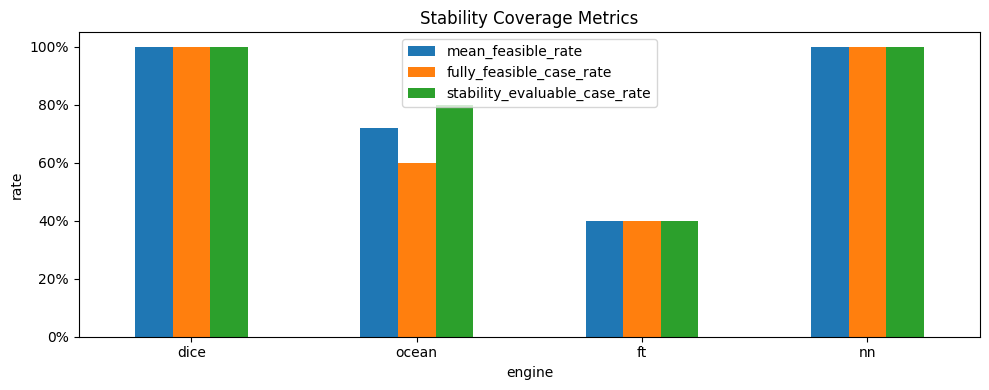

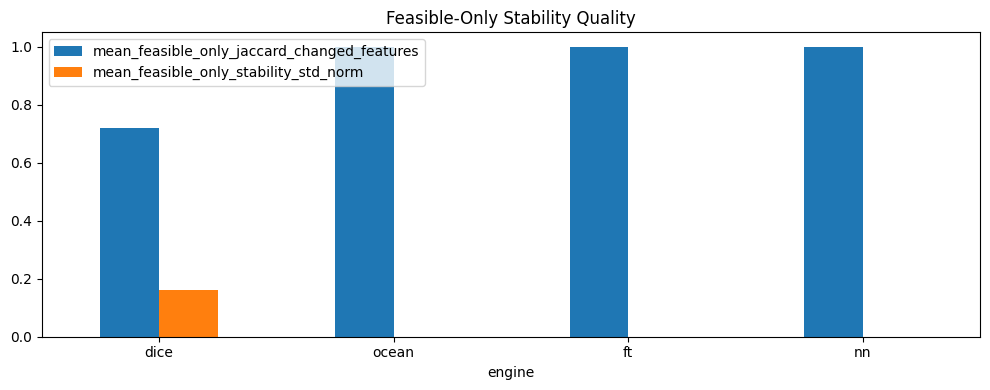

In [35]:
stability_view = stability_df.copy()
if not stability_view.empty:
    stability_view["engine"] = pd.Categorical(stability_view["source_file"].map(extract_engine_from_source), categories=ENGINE_ORDER, ordered=True)
    stability_view = stability_view[["engine", "case_count", "mean_feasible_rate", "fully_feasible_case_rate", "stability_evaluable_case_rate", "mean_jaccard_changed_features", "mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"]].sort_values("engine").reset_index(drop=True)
    display(style_metric_table(stability_view, percent_cols=["mean_feasible_rate", "fully_feasible_case_rate", "stability_evaluable_case_rate"], hide_index=True))
    plot_cols = ["mean_feasible_rate", "fully_feasible_case_rate", "stability_evaluable_case_rate"]
    ax = stability_view.set_index("engine")[plot_cols].plot(kind="bar", figsize=(10, 4), rot=0, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in stability_view["engine"].astype(str)])
    ax.set_title("Stability Coverage Metrics")
    ax.set_ylabel("rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()
    ax = stability_view.set_index("engine")[["mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"]].plot(kind="bar", figsize=(10, 4), rot=0, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in stability_view["engine"].astype(str)])
    ax.set_title("Feasible-Only Stability Quality")
    plt.tight_layout()
    plt.show()


## 5. Runtime vs Feasibility Trade-off

Bagian ini mengevaluasi kompromi antara utilitas praktis dan biaya komputasi. Untuk konteks implementasi sistem nyata, engine yang menghasilkan solusi baik tetapi sangat mahal secara runtime belum tentu menjadi pilihan terbaik apabila alternatif lain memberi kualitas serupa dengan biaya yang lebih rendah.


engine,mean_feasible_rate,mean_runtime_ms,timeout_count
dice,45.0%,712.767,0
ocean,28.3%,2582.300,0
ft,25.0%,185.917,0
nn,45.0%,202.300,0


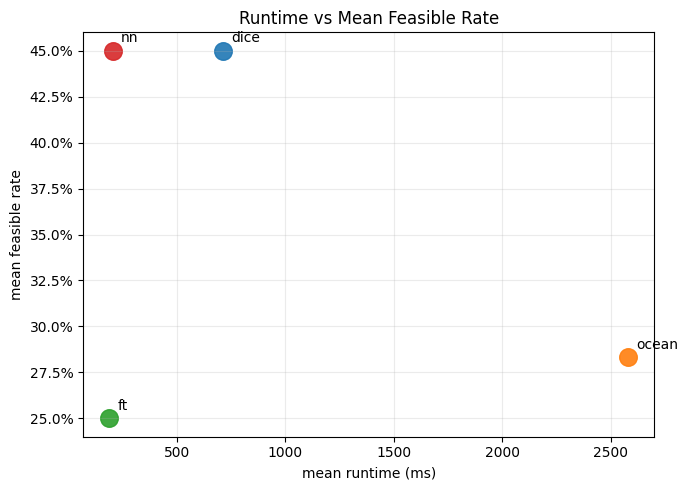

In [36]:
if not scenario_df.empty:
    engine_summary = (
        scenario_df.assign(engine=scenario_df["source_file"].map(extract_engine_from_source))
        .groupby("engine", as_index=False)
        .agg(
            mean_feasible_rate=("feasible_rate", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
            timeout_count=("step_status", lambda s: int((s == "timeout").sum())),
        )
    )
    engine_summary["engine"] = pd.Categorical(engine_summary["engine"], categories=ENGINE_ORDER, ordered=True)
    engine_summary = engine_summary.sort_values("engine").reset_index(drop=True)
    display(style_metric_table(engine_summary, percent_cols=["mean_feasible_rate"], hide_index=True))
    fig, ax = plt.subplots(figsize=(7, 5))
    for _, row in engine_summary.iterrows():
        engine_name = str(row["engine"])
        ax.scatter(row["mean_runtime_ms"], row["mean_feasible_rate"], s=160, color=ENGINE_COLORS.get(engine_name, "#4b5563"), alpha=0.9)
        ax.annotate(engine_name, (row["mean_runtime_ms"], row["mean_feasible_rate"]), textcoords="offset points", xytext=(6, 6))
    ax.set_title("Runtime vs Mean Feasible Rate")
    ax.set_xlabel("mean runtime (ms)")
    ax.set_ylabel("mean feasible rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 6. Action Pattern Analysis

Action pattern analysis digunakan untuk membaca fitur mana yang paling sering menjadi titik intervensi pada solusi counterfactual. Informasi ini penting karena memberikan indikasi mengenai leverage model, sekaligus membantu menghubungkan hasil komputasional dengan interpretasi domain medis dan aksiabilitas pengguna.


engine,feature,count
dice,BMI,26
dice,smoking_status,6
dice,moderate_physical_activity_frequency,3
dice,brinkman_index,1
ft,BMI,38
ft,is_hypertension,12
ft,smoking_status,7
ft,brinkman_index,5
nn,BMI,76
nn,brinkman_index,21


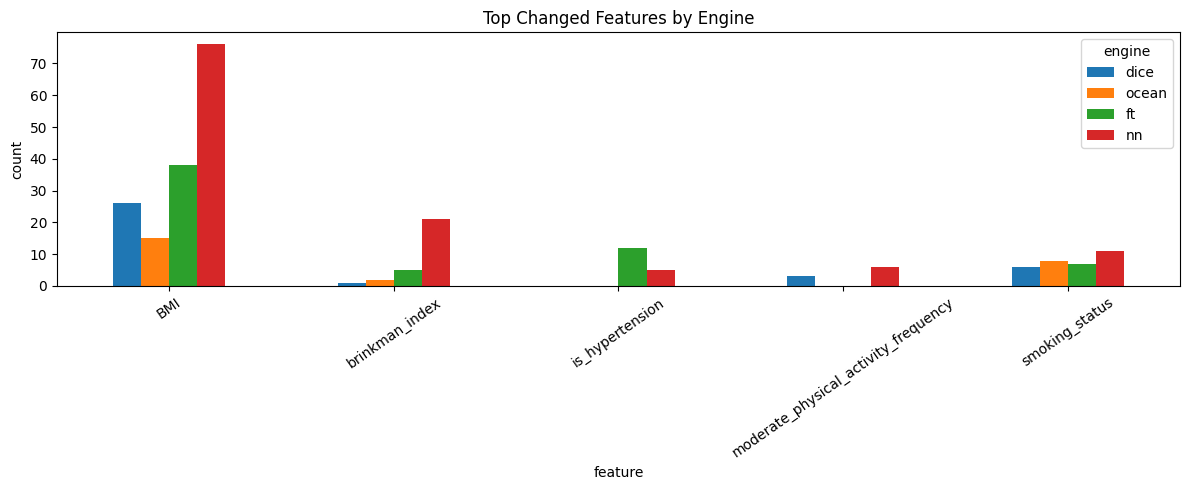

In [37]:
def top_changed_features(frame: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    if frame.empty or "delta" not in frame.columns:
        return pd.DataFrame()
    for _, row in frame.iterrows():
        try:
            delta = ast.literal_eval(row["delta"])
        except Exception:
            continue
        if not isinstance(delta, dict):
            continue
        for feature_name in delta:
            rows.append({"engine": row["engine_name"], "feature": str(feature_name)})
    if not rows:
        return pd.DataFrame()
    out = (
        pd.DataFrame(rows)
        .value_counts(["engine", "feature"])
        .rename("count")
        .reset_index()
        .sort_values(["engine", "count"], ascending=[True, False])
    )
    return out
feature_counts = top_changed_features(candidates_df)
if not feature_counts.empty:
    top_feature_table = feature_counts.groupby("engine").head(5).reset_index(drop=True)
    display(style_metric_table(top_feature_table, hide_index=True))
else:
    display(feature_counts)
if not feature_counts.empty:
    top_feature_pivot = (
        feature_counts.groupby("engine").head(5)
        .pivot(index="feature", columns="engine", values="count")
        .reindex(columns=ENGINE_ORDER)
        .fillna(0)
    )
    ax = top_feature_pivot.plot(kind="bar", figsize=(12, 5), rot=35, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in top_feature_pivot.columns])
    ax.set_title("Top Changed Features by Engine")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()


## 7. Candidate-Level Spot Checks

Section ini menyajikan inspeksi granular terhadap kandidat solusi. Fokusnya bukan lagi pada agregasi antarskenario, melainkan pada karakter solusi itu sendiri: seberapa besar perubahan yang diminta, seberapa sparse solusi tersebut, dan seberapa plausible posisinya relatif terhadap distribusi data referensi.


engine_name,request_id,candidate_id,probability_low_risk,distance_l1,changed_feature_count,lof_score,delta
dice,exp-00001,cf_1,0.5341,0.0275,1,1.2371,"{""BMI"": -12.364281}"
dice,exp-00001,cf_1,0.5306,0.0191,1,1.0342,"{""BMI"": -8.603435}"
dice,exp-00001,cf_1,0.5297,0.0217,1,1.0761,"{""BMI"": -9.77894}"
dice,exp-00002,cf_1,0.5825,0.0202,1,1.2042,"{""BMI"": -9.070205}"
dice,exp-00002,cf_1,0.5741,0.0142,1,1.0669,"{""BMI"": -6.371114}"
dice,exp-00002,cf_1,0.5514,0.0102,1,1.0706,"{""BMI"": -4.584084}"
dice,exp-00003,cf_1,0.5195,0.0873,2,1.4617,"{""smoking_status"": -1.0, ""moderate_physical_activity_frequency"": 4.0}"
dice,exp-00003,cf_1,0.5195,0.0561,2,1.0537,"{""smoking_status"": -1.0, ""BMI"": -0.231334}"
dice,exp-00004,cf_1,0.5606,0.0200,1,1.0190,"{""BMI"": -8.987169}"
dice,exp-00004,cf_1,0.5310,0.0132,1,0.9977,"{""BMI"": -5.933301}"


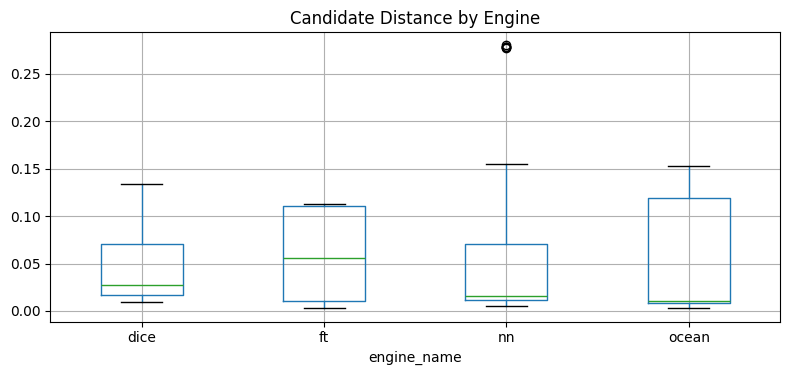

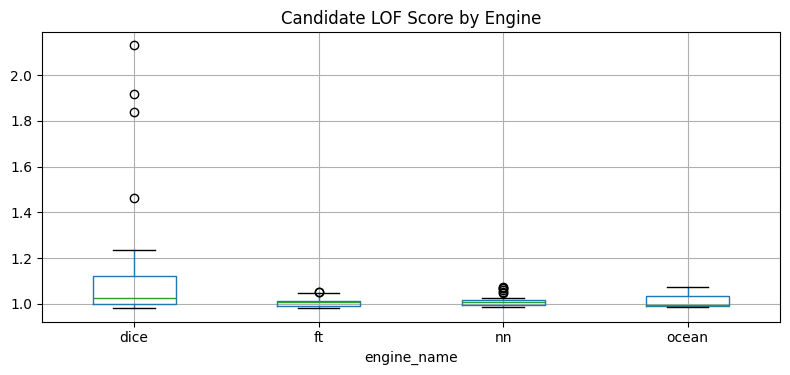

In [38]:
if not candidates_df.empty:
    candidate_view = candidates_df[["engine_name", "request_id", "candidate_id", "probability_low_risk", "distance_l1", "changed_feature_count", "lof_score", "delta"]].copy()
    candidate_view = candidate_view.sort_values(["engine_name", "request_id", "probability_low_risk"], ascending=[True, True, False]).reset_index(drop=True)
    display(style_metric_table(candidate_view.head(16), precision=4, hide_index=True))
    ax = candidate_view.boxplot(column="distance_l1", by="engine_name", figsize=(8, 4), rot=0)
    plt.suptitle("")
    plt.title("Candidate Distance by Engine")
    plt.tight_layout()
    plt.show()
    ax = candidate_view.boxplot(column="lof_score", by="engine_name", figsize=(8, 4), rot=0)
    plt.suptitle("")
    plt.title("Candidate LOF Score by Engine")
    plt.tight_layout()
    plt.show()


## 8. Conclusion